In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from math import sqrt

In [40]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [41]:
ts = df.groupby("tenure")["monthlycharges"].mean().reset_index()

ts.columns = ["Month","AverageCharges"]

ts["Date"] = pd.date_range("2020-01-01",
                           periods=len(ts),
                           freq="M")

ts = ts.set_index("Date")

C:\Users\DELL\AppData\Local\Temp\ipykernel_19188\1833336374.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts["Date"] = pd.date_range("2020-01-01",


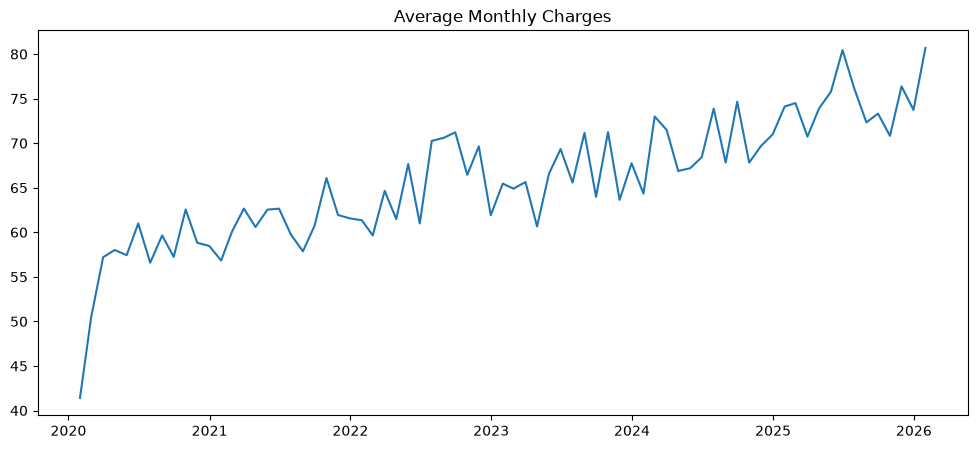

In [42]:
plt.figure(figsize=(12,5))

plt.plot(ts["AverageCharges"])

plt.title("Average Monthly Charges")
plt.savefig("../results/time_series.png")

plt.show()

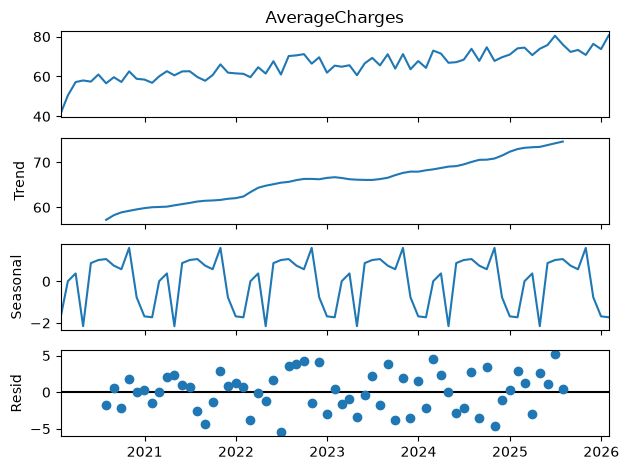

In [43]:
decompose = seasonal_decompose(ts["AverageCharges"],
                               model="additive",
                               period=12)

decompose.plot()
plt.savefig("../results/seasonal_decomposition.png")


plt.show()

In [44]:
result = adfuller(ts["AverageCharges"])

print("ADF Statistic:",result[0])

print("p-value:",result[1])

ADF Statistic: -0.2920082786397437
p-value: 0.9266285974818688


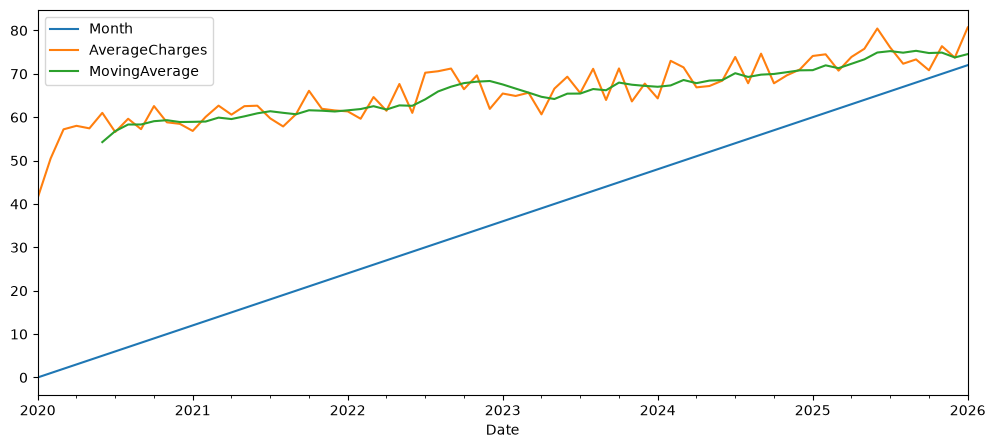

In [45]:
ts["MovingAverage"] = ts["AverageCharges"].rolling(6).mean()

ts.plot(figsize=(12,5))
plt.savefig("../results/moving_average.png")

plt.show()

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


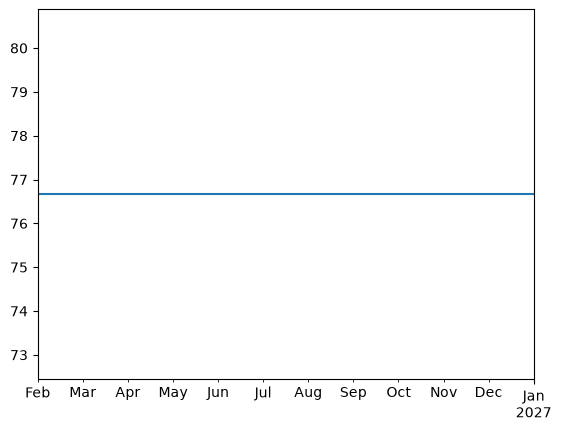

In [46]:
model = ExponentialSmoothing(
    ts["AverageCharges"]
)

fit = model.fit()

forecast = fit.forecast(12)

forecast.plot()
plt.savefig("../results/exponential_smoothing.png")

plt.show()

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


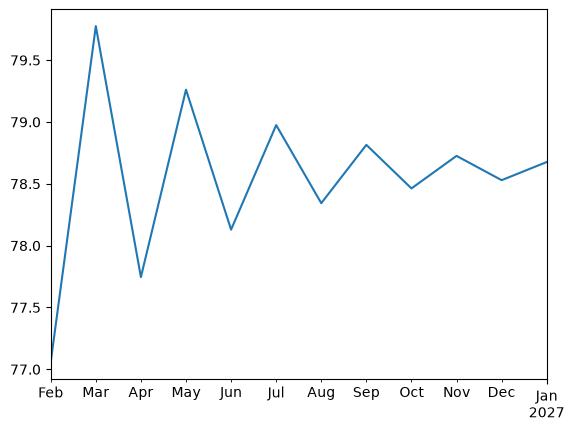

In [47]:
model = ARIMA(
    ts["AverageCharges"],
    order=(1,1,1)
)

fit = model.fit()

forecast = fit.forecast(12)

forecast.plot()
plt.savefig("../results/arima_forecast.png")

plt.show()

In [48]:
actual = ts["AverageCharges"][-12:]

predicted = fit.predict()

mae = mean_absolute_error(actual,
                          predicted[-12:])

rmse = sqrt(mean_squared_error(actual,
                               predicted[-12:]))

print(mae)

print(rmse)

3.0053350057139787
3.5424323824016177


In [49]:
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [50]:
X = df[["tenure",
        "monthlycharges",
        "totalcharges"]]

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

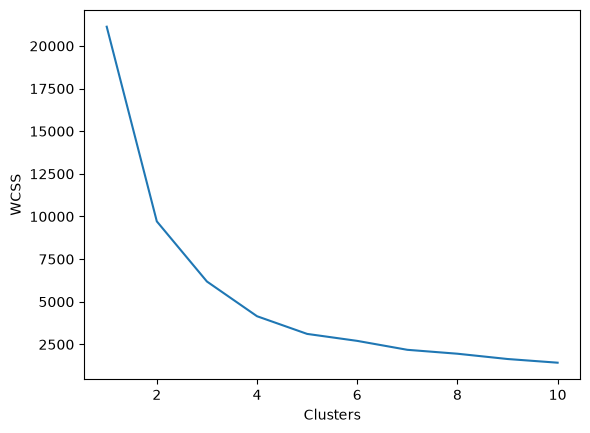

In [52]:
wcss=[]

for i in range(1,11):

    km=KMeans(n_clusters=i,
              random_state=42)

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")

plt.ylabel("WCSS")
plt.savefig("../results/elbow_method.png")

plt.show()

In [53]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [54]:
print(
silhouette_score(
X_scaled,
clusters
)
)

0.4428557150805072


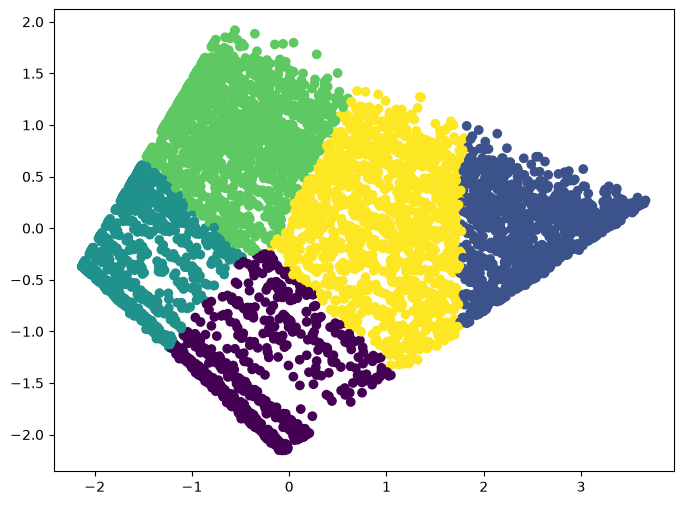

In [55]:
pca = PCA(n_components=2)

points = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(points[:,0],
            points[:,1],
            c=clusters)
plt.savefig("../results/clusters.png")


plt.show()

In [65]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score

from sklearn.metrics import roc_auc_score

from sklearn.metrics import roc_curve
from sklearn.metrics import ConfusionMatrixDisplay



import joblib

In [57]:
df=df.copy()

for col in df.columns:

    if df[col].dtype=="object":

        le=LabelEncoder()

        df[col]=le.fit_transform(df[col])

In [58]:
X=df.drop("churn",axis=1)

y=df["churn"]

In [59]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=.2,
random_state=42
)

In [60]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred=lr.predict(X_test)

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
print(classification_report(
y_test,
pred
))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [62]:
print(
accuracy_score(
y_test,
pred
)
)

0.8147622427253371


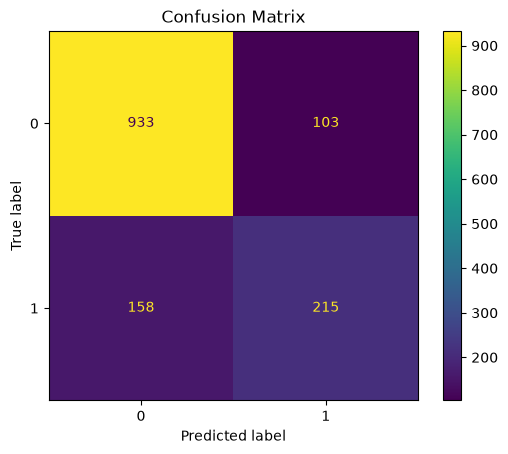

In [66]:
cm = confusion_matrix(y_test,pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig("../results/confusion_matrix.png")

plt.show()

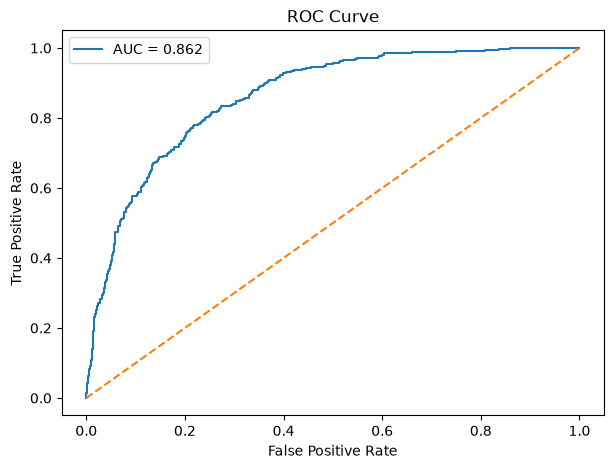

ROC AUC: 0.8617491486124194


In [67]:
prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

auc = roc_auc_score(
    y_test,
    prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("../results/roc_curve.png")

plt.show()

print("ROC AUC:", auc)

In [ ]:
tree=DecisionTreeClassifier()

tree.fit(
X_train,
y_train
)

tree_pred=tree.predict(
X_test
)

print(
classification_report(
y_test,
tree_pred
)
)

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1036
           1       0.49      0.51      0.50       373

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



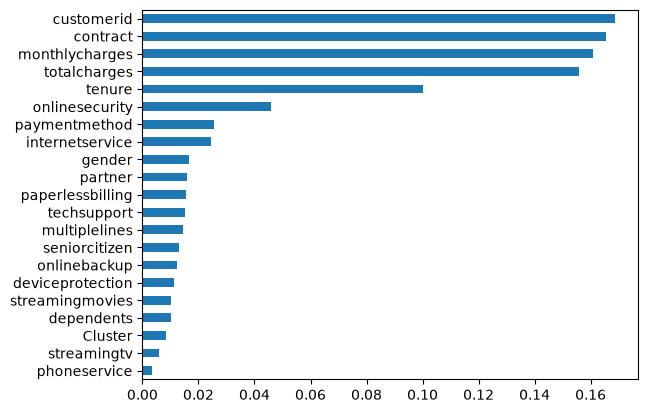

In [ ]:
importance=pd.Series(
tree.feature_importances_,
index=X.columns
)

importance.sort_values().plot.barh()
plt.savefig("../results/feature_importance.png")


plt.show()

In [ ]:
joblib.dump(
lr,
"../models/logistic_regression.pkl"
)

joblib.dump(
tree,
"../models/decision_tree.pkl"
)

joblib.dump(
kmeans,
"../models/kmeans.pkl"
)

['../models/kmeans.pkl']

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
df_lr = pd.read_csv("../data/processed/telco_cleaned.csv")

In [70]:
from sklearn.preprocessing import LabelEncoder

df_lr = df_lr.copy()

for col in df_lr.columns:
    if df_lr[col].dtype == "object":
        le = LabelEncoder()
        df_lr[col] = le.fit_transform(df_lr[col])

In [71]:
X = df_lr.drop("monthlycharges", axis=1)
y = df_lr["monthlycharges"]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 0. ,-0.44, 3.58,...,-1.35, 0.01, 6.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['customerid','gender','seniorcitizen',...,'paymentmethod','totalcharges', 'churn']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.55
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [74]:
predictions = lr_model.predict(X_test)

In [75]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 10.871571411190981
Root Mean Squared Error : 13.231049886629222
R² Score : 0.8066428231568132


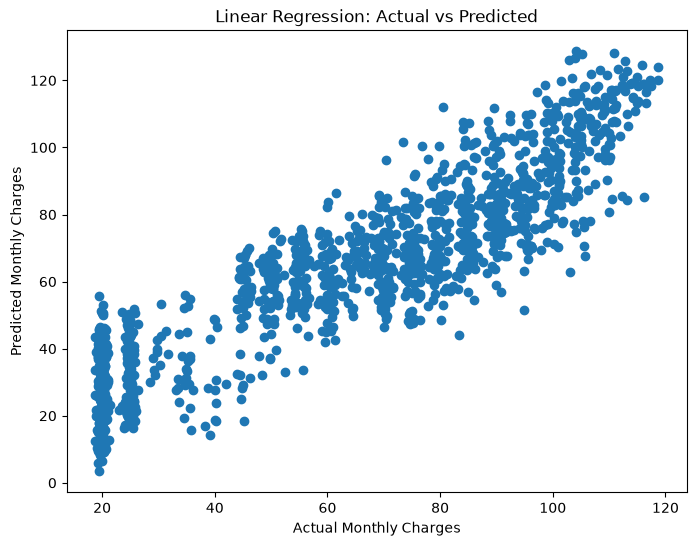

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Monthly Charges")
plt.ylabel("Predicted Monthly Charges")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [77]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
6,phoneservice,22.796756
19,churn,6.871507
16,paperlessbilling,4.468509
2,seniorcitizen,3.577317
7,multiplelines,3.518523
13,streamingtv,3.193763
14,streamingmovies,2.892838
3,partner,0.767966
11,deviceprotection,0.071856
18,totalcharges,0.012742


In [78]:
joblib.dump(
    lr_model,
    "../models/linear_regression.pkl"
)

['../models/linear_regression.pkl']